In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

# Загрузка данных

Загрузим файлы датасета в помощью библиотеки Pandas. 


In [3]:
data = pd.read_csv('country_stats.csv', sep=",")


# Основные характеристики датасета

In [4]:
# Первые 5 строк датасета
data.head()

,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.0,16376870.0,721380.0,4.2,1.460283e+08,1.8,8.54,0.832,1.47,13.27,95.6,299.0637
1,Canada,9984670.0,9093507.0,891163.0,8.9,4.141706e+07,0.5,4.15,0.939,1.33,8.17,94.4,"3,468.2119"
2,China,9596960.0,9326410.0,270550.0,2.8,1.404890e+09,17.0,146.39,0.797,1.03,7.82,91.6,"2,412.0799"
3,United States,9525067.0,9147593.0,377424.0,4.0,3.417849e+08,4.1,35.88,0.938,1.63,8.42,94.7,"30,196.961"
4,Brazil,8510346.0,8460415.0,55352.0,0.6,2.142120e+08,2.6,25.17,0.786,1.59,6.90,84.5,692.6895


In [5]:
# Размер датасета - 8143 строк, 7 колонок
data.shape

(195, 13)

In [6]:
total_count = data.shape[0]
print('Всего строк: {}'.format(total_count))

Всего строк: 195


In [7]:
# Список колонок
data.columns

Index(['Country name', 'Total in km2', 'Land in km2', 'Inland water in km2',
       '% water', 'Population', '% of world population', 'Population density',
       'HDI', 'Fertility rate', 'Mortality rate',
       '% of internet users in population', 'External debt (billions)'],
      dtype='object')

In [8]:
# Список колонок с типами данных
data.dtypes


Country name                          object
Total in km2                         float64
Land in km2                          float64
Inland water in km2                  float64
% water                              float64
Population                           float64
% of world population                float64
Population density                   float64
HDI                                  float64
Fertility rate                       float64
Mortality rate                       float64
% of internet users in population    float64
External debt (billions)              object
dtype: object

In [9]:
# Проверим наличие пустых значений
# Цикл по колонкам датасета
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    temp_null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, temp_null_count))

Country name - 0
Total in km2 - 0
Land in km2 - 1
Inland water in km2 - 1
% water - 1
Population - 1
% of world population - 1
Population density - 1
HDI - 5
Fertility rate - 4
Mortality rate - 8
% of internet users in population - 6
External debt (billions) - 5


In [10]:
# Основные статистические характеристки набора данных
data.describe()

,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population
count,1.950000e+02,1.940000e+02,194.000000,194.000000,1.940000e+02,194.000000,194.000000,190.000000,191.000000,187.000000,189.000000
mean,6.850936e+05,6.646920e+05,20595.489691,2.567784,4.139528e+07,0.496013,317.356701,0.739895,2.349110,7.557166,70.697989
std,1.909728e+06,1.840054e+06,91053.493059,4.103184,1.491410e+08,1.805684,1524.825775,0.150655,1.113958,2.877799,26.917858
min,4.400000e-01,4.400000e-01,0.000000,0.000000,8.820000e+02,0.000000,2.300000,0.388000,0.760000,1.420000,0.000000
25%,2.308250e+04,2.290250e+04,11.500000,0.100000,1.846638e+06,0.020000,33.502500,0.623500,1.490000,5.680000,54.600000
50%,1.184840e+05,1.123250e+05,1592.500000,1.400000,9.244136e+06,0.100000,86.570000,0.761500,1.930000,6.990000,82.000000
75%,5.092450e+05,4.924125e+05,9022.500000,3.175000,3.187902e+07,0.400000,202.202500,0.856750,3.085000,9.235000,91.600000
max,1.709825e+07,1.637687e+07,891163.000000,27.800000,1.429404e+09,17.300000,19428.500000,0.972000,5.840000,21.700000,100.000000


In [12]:
# Определим уникальные значения для целевого признака
data['Population'].unique()


array([1.46028325e+08, 4.14170560e+07, 1.40489000e+09, 3.41784857e+08,
       2.14211951e+08, 2.78010230e+07, 1.42940400e+09, 4.64666880e+07,
       2.06048190e+07, 4.74000000e+07, 1.16452162e+08, 3.53002800e+07,
       1.31231919e+08, 2.88315089e+08, 5.32827190e+07, 7.53985200e+06,
       8.71340000e+07, 3.59112000e+06, 3.41577320e+07, 2.00316020e+07,
       2.75227500e+07, 3.87785540e+07, 2.39290000e+07, 6.35223800e+07,
       5.33991710e+07, 1.11652998e+08, 1.13653330e+07, 4.92753200e+06,
       1.08613296e+08, 7.00388500e+07, 2.23800000e+08, 2.86337110e+07,
       2.41499431e+08, 3.02240100e+06, 3.49589730e+07, 8.60921680e+07,
       2.01509480e+07, 2.30032140e+07, 5.13753270e+07, 4.38440000e+07,
       1.57868980e+07, 6.90819960e+07, 2.03059070e+07, 6.47030700e+06,
       2.87000000e+07, 3.26589770e+07, 2.35960900e+06, 5.42270150e+07,
       7.02507510e+07, 4.98015590e+07, 7.05784100e+06, 2.94423270e+07,
       1.01853630e+07, 3.26845030e+07, 1.06135310e+07, 3.90473210e+07,
      

# Визуальное исследование датасета
Для визуального исследования могут быть использованы различные виды диаграмм, мы построим только некоторые варианты диаграмм, которые используются достаточно часто.


# Диаграмма рассеяния


<Axes: xlabel='Population', ylabel='Total in km2'>

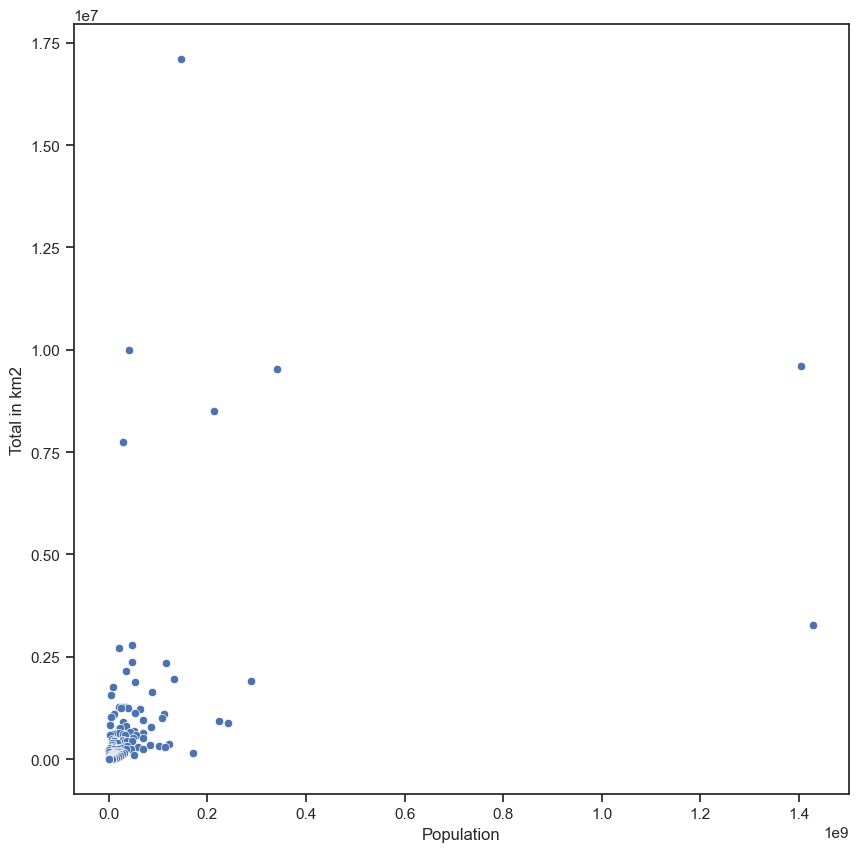

In [15]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Population', y='Total in km2', data=data)

In [17]:
# Определяем числовые и категориальные признаки
num_cols = data.select_dtypes(include=np.number).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

Числовые признаки: ['Total in km2', 'Land in km2', 'Inland water in km2', '% water', 'Population', '% of world population', 'Population density', 'HDI', 'Fertility rate', 'Mortality rate', '% of internet users in population']
Категориальные признаки: ['Country name', 'External debt (billions)']


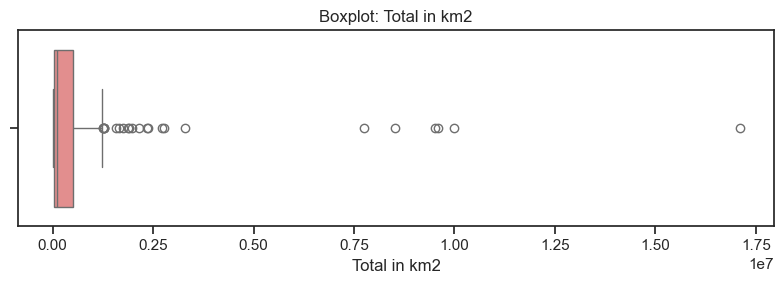

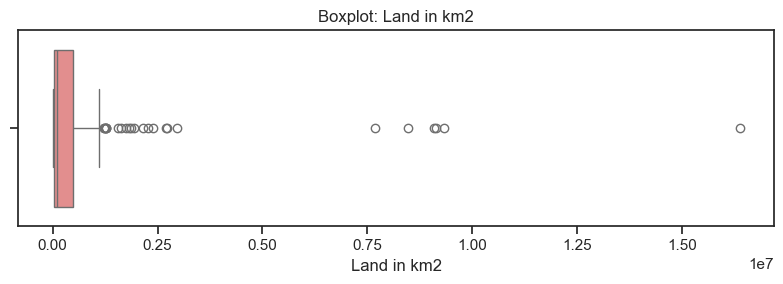

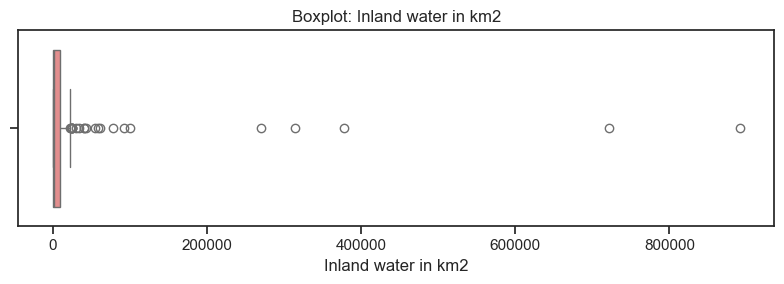

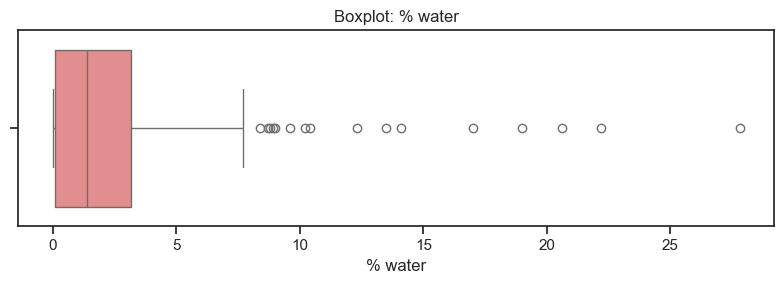

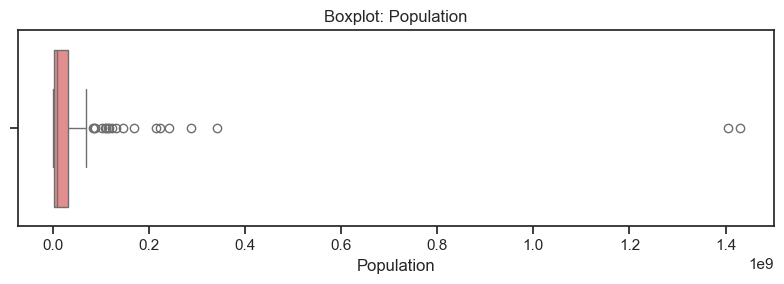

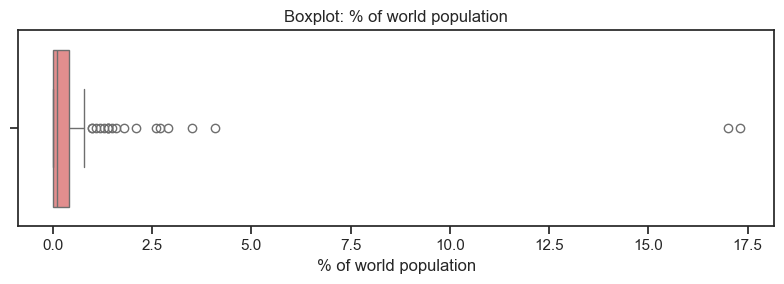

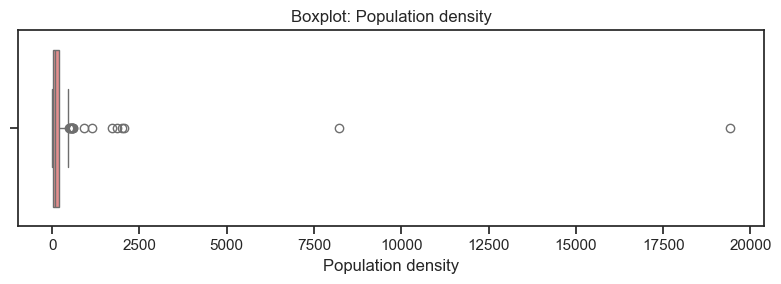

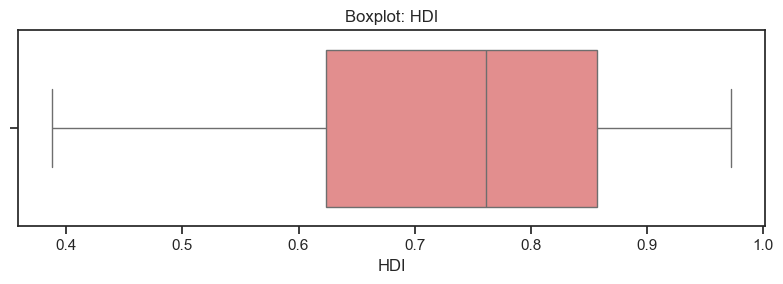

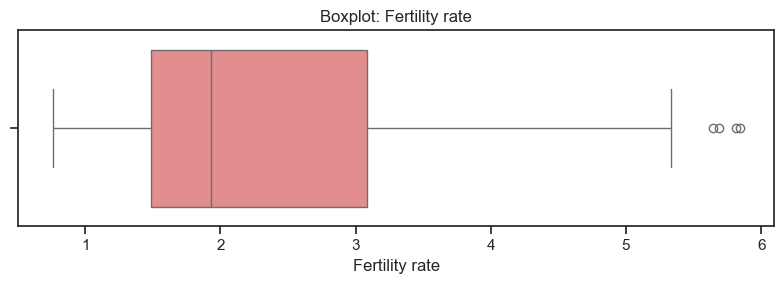

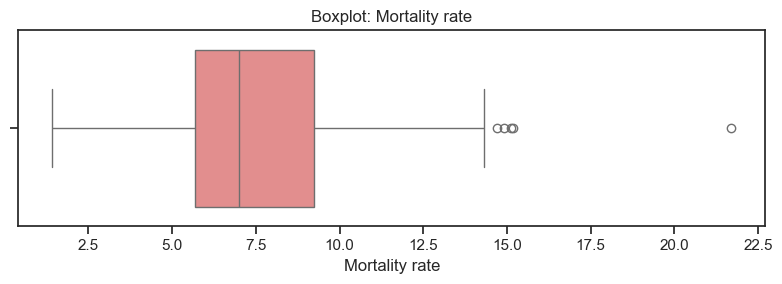

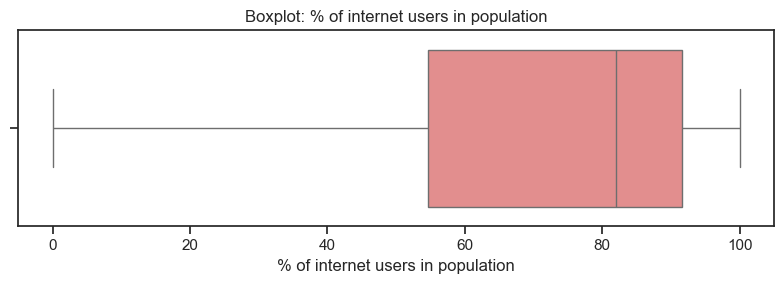

In [18]:
# Ящики с усами для каждого числового признака
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=data[col], color='lightcoral')
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

C:\Users\AcerETBook\AppData\Local\Temp\ipykernel_14744\1132926338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


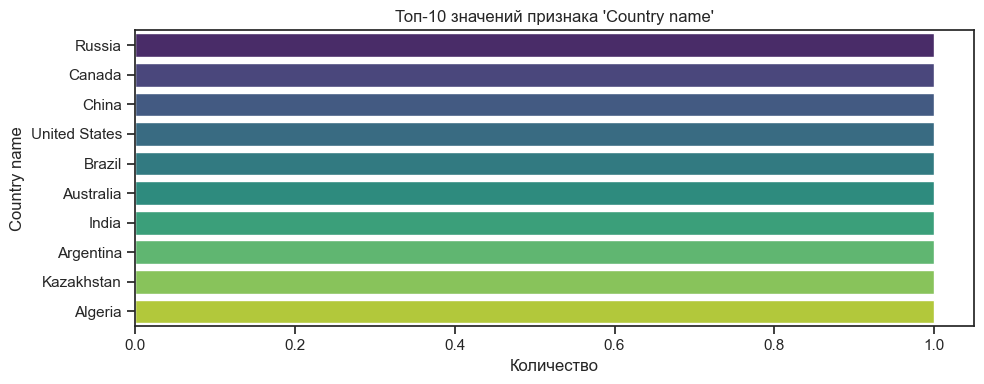

C:\Users\AcerETBook\AppData\Local\Temp\ipykernel_14744\1132926338.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top.values, y=top.index, palette="viridis")


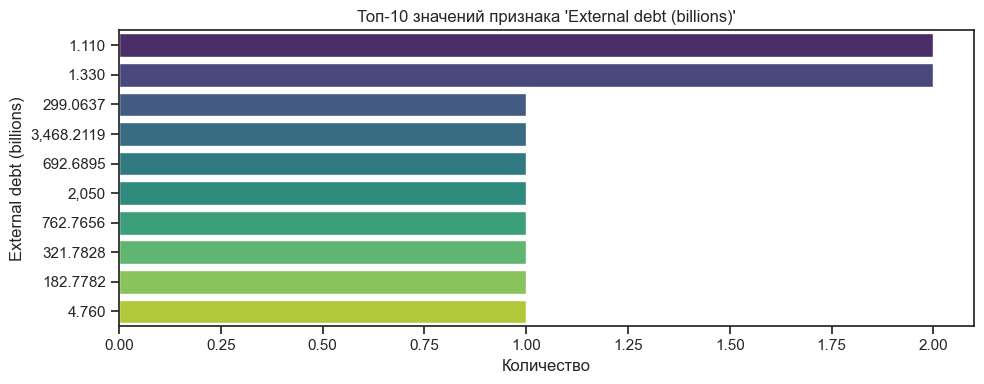

In [19]:
# Топ-10 значений по каждому категориальному признаку
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    top = data[col].value_counts().head(10)
    sns.barplot(x=top.values, y=top.index, palette="viridis")
    plt.title(f"Топ-10 значений признака '{col}'")
    plt.xlabel("Количество")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

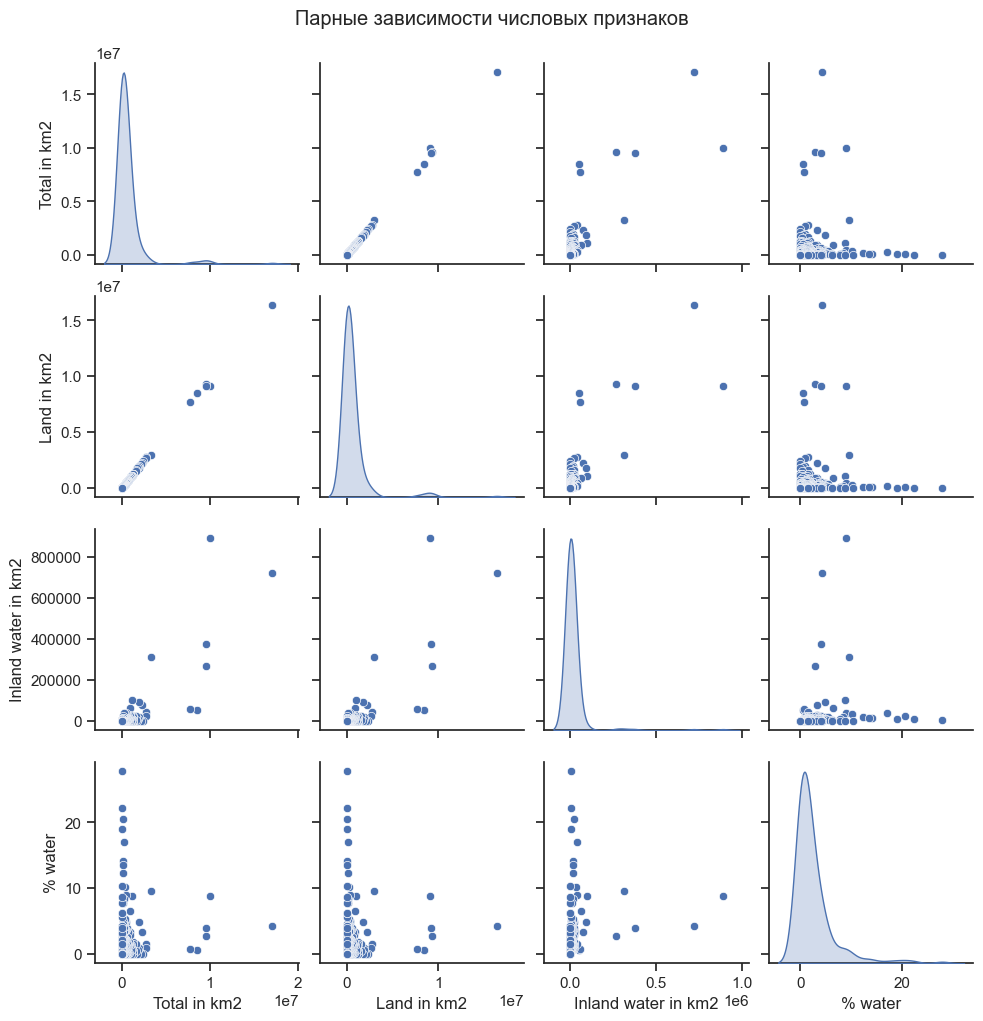

In [20]:
# Попарные scatter-plot'ы (первые 4 числовых признака)
if len(num_cols) >= 2:
    sns.pairplot(data[num_cols[:4]].dropna(), diag_kind='kde')
    plt.suptitle("Парные зависимости числовых признаков", y=1.02)
    plt.show()

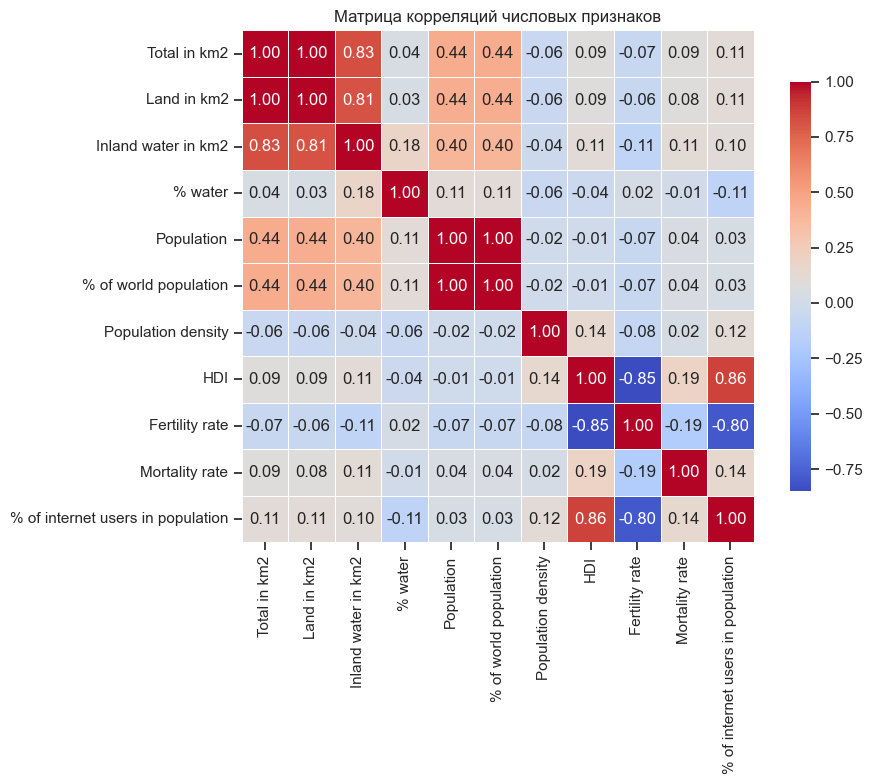

Наиболее коррелирующие пары признаков:
Population             % of world population                0.999927
Land in km2            Total in km2                         0.999614
HDI                    % of internet users in population    0.864437
Total in km2           Inland water in km2                  0.828604
Land in km2            Inland water in km2                  0.812726
% of world population  Total in km2                         0.444990
Population             Total in km2                         0.444833
% of world population  Land in km2                          0.443498
Land in km2            Population                           0.443353
% of world population  Inland water in km2                  0.395472
dtype: float64


In [21]:
## 4. Корреляция признаков

if len(num_cols) >= 2:
    corr = data[num_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Матрица корреляций числовых признаков")
    plt.tight_layout()
    plt.show()

    # Топ наиболее коррелирующих пар (без диагонали)
    corr_pairs = corr.unstack().sort_values(ascending=False)
    corr_pairs = corr_pairs[corr_pairs < 1.0]
    print("Наиболее коррелирующие пары признаков:")
    print(corr_pairs.drop_duplicates().head(10))
else:
    print("Недостаточно числовых признаков для построения корреляционной матрицы.")

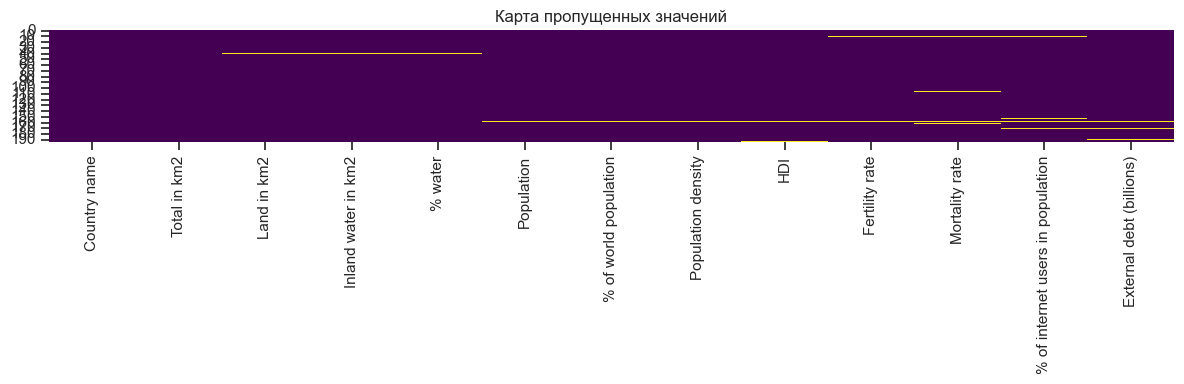

In [22]:
# Карта пропусков — полезно, если в датасете всё-таки есть NaN
plt.figure(figsize=(12, 4))
sns.heatmap(data.isnull(), cbar=False, cmap='viridis')
plt.title("Карта пропущенных значений")
plt.tight_layout()
plt.show()

## Выводы

В ходе разведочного анализа датасета `country_stats.csv` были выполнены:

1. **Первичный осмотр** — размер, типы признаков, наличие пропусков и дубликатов.
2. **Описательная статистика** — средние, медианы, квартили, min/max по числовым признакам.
3. **Визуализация распределений** — гистограммы показали форму распределений (асимметрия, скошенность вправо у признаков типа "население", "ВВП").
4. **Boxplot** — обнаружены выбросы, что типично для экономико-демографических данных (несколько стран-гигантов).
5. **Категориальный анализ** — построены топ-10 частот по категориальным признакам.
6. **Корреляционный анализ** — heatmap выявил наиболее связанные пары признаков, что полезно для последующего отбора признаков (feature selection) в задачах ML.

Полученные результаты подтверждают, что датасет пригоден для дальнейшего моделирования: пропусков нет (или их мало), признаки информативны, а распределения соответствуют реальной картине мира.